# 03. Model Comparison and Sensitivity anaysis

## Notebook Roadmap
1. Evaluation protocol
2. Baseline model comparison
3. Sensitivity analysis I: seed stability
4. Sensitivity analysis II: fold sensitivity
5. Sensitivity analysis III: Feature-Noise Robustness
6. Final Model Selection and Test Prediction

## Input Data

The dataset is prepared for supervised regression, where the target variable is house sale price.  
Following the common practice in the Kaggle House Prices competition, the analysis is conducted on a transformed target when appropriate (for example, `log1p(SalePrice)`), so that the evaluation focuses on relative rather than absolute price errors.

At this stage, the purpose of the notebook is not feature engineering itself, but model comparison under a controlled setup.  
Therefore, I treat the current feature matrix `X_train` and target vector `y_train` as the modeling input and focus on performance, stability, and interpretability.

In [3]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

train_processed = pd.read_csv("../data/processed/train_processed.csv")
X_train = train_processed.drop("SalePrice_log", axis=1)
y_train = train_processed["SalePrice_log"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1451, 275)
y_train shape: (1451,)


## 1. Evaluation Protocol

To ensure a fair comparison across models, I use the same cross-validation setup for all candidate estimators.

**Evaluation choices**
- Metric: RMSE on the current target scale  
- If the target has been transformed with `log1p(SalePrice)`, then this is equivalent to RMSE in log-price space
- Cross-validation: 5-fold KFold
- Shuffle: enabled
- Random seed: 42

This point is important because model rankings in online tutorials often differ from one another.  
Such differences can come from changes in preprocessing, target transformation, feature engineering, fold assignment, or random seed.  
Therefore, instead of copying a public ranking directly, I rely on a consistent local evaluation protocol and interpret the results within that protocol.

In [4]:
from model import compare_models_cv, print_model_results

results_df = compare_models_cv(X_train, y_train, n_folds=5, random_state=42)
print_model_results(results_df)
results_df.round(5)

 rank            model  rmse_mean  rmse_std  rmse_min  rmse_max  fold_1_rmse  fold_2_rmse  fold_3_rmse  fold_4_rmse  fold_5_rmse
    1 GradientBoosting    0.11348   0.00250   0.10993   0.11605      0.10993      0.11413      0.11126      0.11605      0.11605
    2       ElasticNet    0.11483   0.00312   0.11043   0.11959      0.11418      0.11959      0.11043      0.11321      0.11674
    3            Lasso    0.11527   0.00325   0.11041   0.11971      0.11435      0.11971      0.11041      0.11398      0.11790
    4            Ridge    0.11839   0.00409   0.11183   0.12279      0.12169      0.12279      0.12003      0.11560      0.11183
    5         LightGBM    0.11890   0.00197   0.11640   0.12125      0.11699      0.12125      0.11895      0.11640      0.12092
    6          XGBoost    0.11998   0.00413   0.11420   0.12675      0.11420      0.11988      0.11786      0.12122      0.12675
    7     RandomForest    0.13699   0.00632   0.12991   0.14858      0.13786      0.12991      0.

,rank,model,rmse_mean,rmse_std,rmse_min,rmse_max,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,1,GradientBoosting,0.11348,0.00250,0.10993,0.11605,0.10993,0.11413,0.11126,0.11605,0.11605
1,2,ElasticNet,0.11483,0.00312,0.11043,0.11959,0.11418,0.11959,0.11043,0.11321,0.11674
2,3,Lasso,0.11527,0.00325,0.11041,0.11971,0.11435,0.11971,0.11041,0.11398,0.11790
3,4,Ridge,0.11839,0.00409,0.11183,0.12279,0.12169,0.12279,0.12003,0.11560,0.11183
4,5,LightGBM,0.11890,0.00197,0.11640,0.12125,0.11699,0.12125,0.11895,0.11640,0.12092
5,6,XGBoost,0.11998,0.00413,0.11420,0.12675,0.11420,0.11988,0.11786,0.12122,0.12675
6,7,RandomForest,0.13699,0.00632,0.12991,0.14858,0.13786,0.12991,0.13399,0.13460,0.14858


In [6]:
results_df.to_csv("../results/tables/model_comparison.csv", index=False)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Model Comparison (CV RMSE)'}, xlabel='Model', ylabel='RMSE'>)

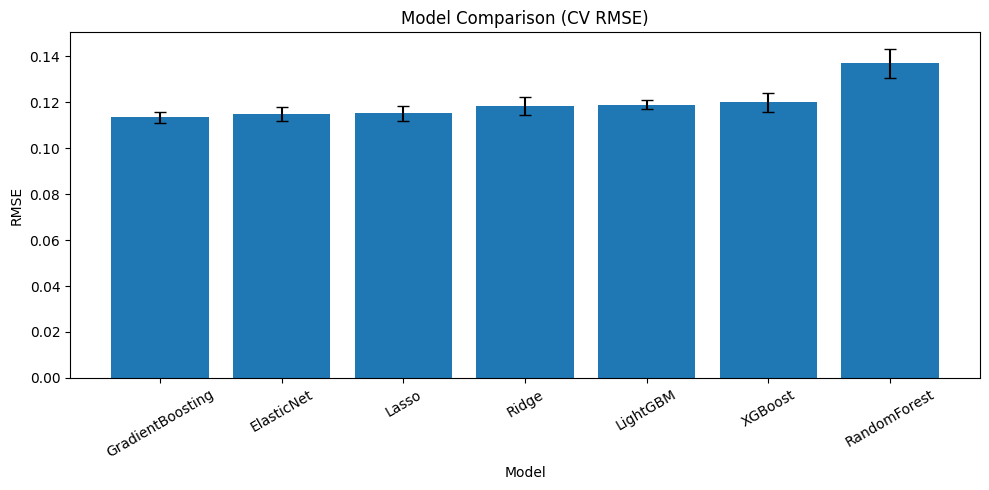

In [7]:
from model import plot_model_comparison

plot_model_comparison(results_df)

In [12]:
fig.savefig("../results/figure/model_comparison.png", dpi=300, bbox_inches="tight")

## 2. Baseline model comparison

### First observations

- **GradientBoosting** currently gives the best mean CV score.
- **ElasticNet** and **Lasso** are close competitors and form a strong top tier together with GradientBoosting.
- **Ridge** performs worse than the sparsity-inducing linear models in this setup.
- **LightGBM** and **XGBoost** are not automatically superior here, which suggests that boosting libraries do not guarantee better performance unless preprocessing, hyperparameters, and feature interactions align well with the data.
- **RandomForest** is clearly the weakest model in this comparison.

### Important interpretation note

The gap between the top models is relatively small.  
This means I should avoid over-interpreting tiny score differences as decisive evidence.  
In particular, the top three models are close enough that model stability and robustness matter, not only the single best mean score.

## 3. Sensitivity Analysis I: Seed Stability

A single CV result can be affected by how the folds are shuffled.  
To test whether the model ranking is stable, I repeat the comparison across several random seeds and summarize the average performance and variation across seeds.

This test answers the following question:

> Is GradientBoosting consistently strong, or is its top ranking mainly a result of one particular fold split?

In [14]:
from model import (
    seed_sensitivity_analysis,
    fold_sensitivity_analysis,
    noise_robustness_analysis,
)

In [6]:
seed_results_long, seed_summary = seed_sensitivity_analysis(
    X_train, y_train,
    seeds=(0, 21, 42, 84, 126),
    n_folds=5
)

seed_summary.round(5)

,model,mean_rmse,std_across_seeds,best_rmse,worst_rmse,win_count
0,GradientBoosting,0.11376,0.00077,0.11280,0.11458,5
1,ElasticNet,0.11539,0.00091,0.11440,0.11675,0
2,Lasso,0.11578,0.00085,0.11487,0.11709,0
3,LightGBM,0.11977,0.00069,0.11890,0.12056,0
4,XGBoost,0.12001,0.00077,0.11914,0.12126,0
5,Ridge,0.12055,0.00245,0.11817,0.12335,0
6,RandomForest,0.13595,0.00103,0.13482,0.13707,0


### Interpretation of Seed Sensitivity

The seed sensitivity results show that **GradientBoosting is not a one-off winner**.  
It achieves the lowest mean RMSE across seeds (**0.11376**) and ranks first in **all 5 seed settings** (`win_count = 5`), which provides strong evidence that its leading position is stable under fold shuffling.

The second tier is formed by **ElasticNet** and **Lasso**, which remain competitive while also showing low variation across seeds.  
Their performance is slightly worse than GradientBoosting, but the gap is relatively modest.

A notable contrast is **Ridge**, whose `std_across_seeds` (**0.00245**) is much larger than that of the other leading models.  
This suggests that Ridge is more sensitive to how the folds are generated and therefore less stable as a candidate model.

Overall, this test supports the conclusion that **GradientBoosting is the most reliable top performer under the current evaluation protocol**, rather than a model that happens to win only under one particular random split.

## 4. Sensitivity Analysis II: Fold Sensitivity

Next, I test whether the ranking depends strongly on the number of folds used in cross-validation.

This matters because a model that looks strong under 5-fold CV may become less convincing under 10-fold CV, especially when the sample size is not very large or when variance is high.

Here I compare the same models under:
- 5-fold CV
- 10-fold CV

In [7]:
fold_results, fold_compare = fold_sensitivity_analysis(
    X_train, y_train,
    fold_list=(5, 10),
    random_state=42
)

fold_compare.round(5)

n_folds,model,rmse_5fold,rmse_10fold,delta_10_minus_5
0,GradientBoosting,0.11348,0.11281,-0.00067
1,ElasticNet,0.11483,0.11407,-0.00076
2,Lasso,0.11527,0.11462,-0.00065
3,Ridge,0.11839,0.11920,0.00081
4,LightGBM,0.11890,0.11759,-0.00131
5,XGBoost,0.11998,0.11879,-0.00119
6,RandomForest,0.13699,0.13402,-0.00296


### Interpretation of Fold Sensitivity

The fold sensitivity analysis shows that the overall ranking is structurally stable when moving from **5-fold CV** to **10-fold CV**.

Most importantly, the **top three models remain unchanged**:
1. GradientBoosting
2. ElasticNet
3. Lasso

This consistency suggests that the main ranking is not highly dependent on the specific fold setting.  
Although several models obtain slightly lower RMSE under 10-fold CV, these changes are relatively small in magnitude and do not overturn the overall comparison.

An exception is **Ridge**, which becomes slightly worse under 10-fold CV, further indicating that it is more sensitive to evaluation design than the stronger candidates.

Taken together, this result strengthens the validity of the baseline comparison:  
the leading models are not only strong under one CV setting, but also remain competitive under an alternative validation configuration.

## 5. Sensitivity Analysis III: Feature-Noise Robustness

A model may perform well under clean inputs but degrade sharply when the features are slightly perturbed.  
To test robustness, I add a small amount of Gaussian noise to the numerical features and rerun the model comparison.

This is not meant to simulate a real-world deployment perfectly.  
Instead, it provides a simple stress test for the question:

> Which models are more fragile when the feature matrix becomes slightly noisy?

In [8]:
clean_results, noisy_results, noise_compare = noise_robustness_analysis(
    X_train, y_train,
    noise_ratio=0.01,
    n_folds=5,
    random_state=42
)

noise_compare.round(5)

,model,rmse_mean_clean,rmse_mean_noisy,delta_rmse
0,Ridge,0.11839,0.11841,0.00002
1,Lasso,0.11527,0.11532,0.00005
2,ElasticNet,0.11483,0.11488,0.00005
3,XGBoost,0.11998,0.12126,0.00127
4,RandomForest,0.13699,0.13878,0.00179
5,GradientBoosting,0.11348,0.11617,0.00269
6,LightGBM,0.11890,0.12334,0.00444


### Interpretation of Feature-Noise Robustness

The feature-noise robustness test reveals an important trade-off between **peak predictive performance** and **stability under perturbation**.

The linear models — especially **Ridge**, **Lasso**, and **ElasticNet** — show extremely small performance degradation after adding mild Gaussian noise to the numerical features.  
Their `delta_rmse` values are close to zero, which suggests that these models are highly stable under small input perturbations.

By contrast, **GradientBoosting**, while being the best model under the clean baseline setting, experiences a larger increase in RMSE (`delta_rmse = 0.00269`).  
This indicates that its predictive advantage comes with greater sensitivity to feature noise.

The most fragile model in this test is **LightGBM**, with the largest deterioration (`delta_rmse = 0.00444`).

Therefore, this robustness analysis suggests that model selection should not rely only on the best clean CV score.  
A more balanced interpretation is that **GradientBoosting is the strongest predictive model**, while **ElasticNet/Lasso provide more noise-stable baselines** for comparison.

## Overall Conclusion from Model Comparison and Sensitivity Analysis

The combined evidence from baseline CV, seed sensitivity, fold sensitivity, and feature-noise robustness leads to a more nuanced model selection decision.

On the one hand, **GradientBoosting** is clearly the strongest model under the main cross-validation setup.  
It also shows stable superiority across multiple random seeds and retains its leading position under different fold settings.

On the other hand, the noise robustness analysis shows that **linear models such as ElasticNet and Lasso are substantially more stable under feature perturbation**.  
This reveals a meaningful trade-off: the best predictive model is not necessarily the most robust model.

Based on these results, I adopt the following strategy for the next stage of the project:

- Use **GradientBoosting** as the main predictive model for downstream interpretation
- Use **ElasticNet/Lasso** as simpler and more robust baseline models
- Reserve stronger perturbation experiments and broader failure-mode analysis for the later stress-testing stage

This makes the project more research-oriented than a simple leaderboard-style comparison, because the final model choice is based on **performance, stability, and robustness together**.